In [2]:
from pathlib import Path

# Walk up from cwd to find project root (directory containing pyproject.toml)
def find_project_root(marker='pyproject.toml'):
    path = Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Cannot find {marker}, project root unknown')

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'

In [3]:
import pandas as pd

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

# Basic shape
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (439140, 16)
Test: (188165, 15)


## LightGBM

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

# Define features
target = "PitNextLap"
drop_cols = ["id", target]
features = [c for c in train.columns if c not in drop_cols]

# Categorical features for LightGBM
cat_features = ["Driver", "Compound", "Race"]

X = train[features].copy()
y = train[target].copy()
X_test = test[features].copy()

# Encode categoricals
for col in cat_features:
    X[col] = X[col].astype("category")
    X_test[col] = X_test[col].astype("category")

print(f"Features ({len(features)}): {features}")
print(f"Categorical: {cat_features}")

Features (14): ['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
Categorical: ['Driver', 'Compound', 'Race']


In [5]:
# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Train pit rate: {y_train.mean():.2%}, Val pit rate: {y_val.mean():.2%}")

Train: (351312, 14), Val: (87828, 14)
Train pit rate: 19.90%, Val pit rate: 19.90%


In [6]:
# Train LightGBM
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.253029
[200]	valid_0's binary_logloss: 0.245307
[300]	valid_0's binary_logloss: 0.241311
[400]	valid_0's binary_logloss: 0.239169
[500]	valid_0's binary_logloss: 0.238278
Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.238278


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [7]:
# Evaluate on validation set
y_val_pred = model.predict_proba(X_val)[:, 1] # type: ignore
auc = roc_auc_score(y_val, y_val_pred)
print(f"Validation ROC-AUC: {auc:.4f}")

Validation ROC-AUC: 0.9429


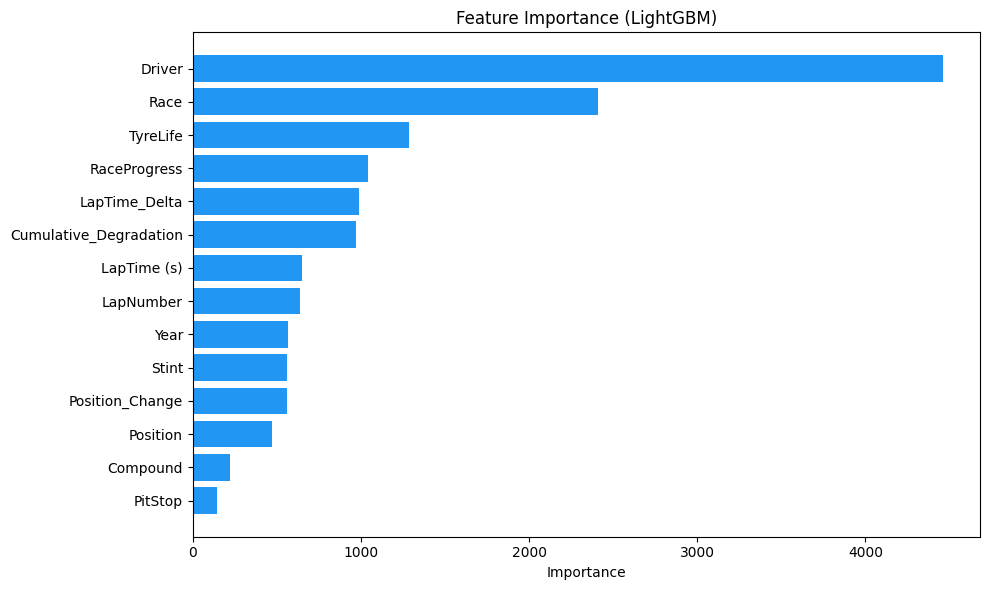

In [8]:
# Feature importance
import matplotlib.pyplot as plt

importance = model.feature_importances_
feat_imp = sorted(zip(features, importance), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([f[0] for f in feat_imp], [f[1] for f in feat_imp], color="#2196F3")
ax.set_title("Feature Importance (LightGBM)")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# Generate submission
y_test_pred = model.predict_proba(X_test)[:, 1] # type: ignore

submission = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": y_test_pred,
})
submission.to_csv(DATA_DIR / "submission.csv", index=False)
print(f"Submission shape: {submission.shape}")
submission.head()

Submission shape: (188165, 2)


,id,PitNextLap
0,439140,0.008007
1,439141,0.003005
2,439142,0.007849
3,439143,0.175917
4,439144,0.821022


## Improved Model v2: Feature Engineering + StratifiedKFold + XGBoost Ensemble

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# Reload data
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

def add_features(df):
    """Add engineered features. Must be applied to train and test together or separately with care."""
    df = df.copy()

    # --- Interaction features ---
    # TyreLife * Compound (different compounds degrade differently)
    df['TyreLife_x_Compound'] = df['TyreLife'].astype(str) + '_' + df['Compound']

    # LapNumber^2 (non-linear effect of race progress)
    df['LapNumber_sq'] = df['LapNumber'] ** 2

    # TyreLife^2 (degradation accelerates)
    df['TyreLife_sq'] = df['TyreLife'] ** 2

    # TyreLife / RaceProgress (tyre usage relative to race progress)
    df['TyreLife_per_Progress'] = df['TyreLife'] / (df['RaceProgress'] + 1e-6)

    # LapTime relative to race average (needs group stats)
    # We'll compute per-race mean laptime as a feature
    df['LapTime_vs_RaceMean'] = df.groupby('Race')['LapTime (s)'].transform(
        lambda x: x - x.mean()
    )

    # Stint * TyreLife interaction
    df['Stint_x_TyreLife'] = df['Stint'] * df['TyreLife']

    # Is this the last stint before likely pit? (high tyre life + not last stint)
    df['HighTyreLife'] = (df['TyreLife'] > 20).astype(int)

    # Position group (top 5, mid, back)
    df['PosGroup'] = pd.cut(df['Position'], bins=[0, 5, 10, 20], labels=['top', 'mid', 'back'])

    # Cumulative pit stops in this race so far (cumsum of PitStop)
    df['CumPitStops'] = df.groupby(['Race', 'Year', 'Driver'])['PitStop'].cumsum()

    # Laps since last pit stop (approximation: TyreLife is essentially this)
    # But we can also compute remaining stint length
    df['LapsToGo'] = df.groupby(['Race', 'Year', 'Driver'])['LapNumber'].transform('max') - df['LapNumber']

    # Driver pit tendency: rolling mean of PitNextLap per driver (only for train)
    # This is tricky to avoid leakage, so we use only historical data
    # We'll skip this for now to avoid leakage issues

    # LapTime_Delta sign and magnitude
    df['Delta_positive'] = (df['LapTime_Delta'] > 0).astype(int)
    df['Abs_LapTime_Delta'] = df['LapTime_Delta'].abs()

    # Race-specific features
    df['RaceLapCount'] = df.groupby(['Race', 'Year'])['LapNumber'].transform('max')
    df['LapInRace'] = df['LapNumber'] / df['RaceLapCount']

    return df

# Combine train and test for feature engineering
train['is_train'] = 1
test['is_train'] = 0
test['PitNextLap'] = np.nan

combined = pd.concat([train, test], ignore_index=True)
combined = add_features(combined)

train_fe = combined[combined['is_train'] == 1].drop(columns=['is_train'])
test_fe = combined[combined['is_train'] == 0].drop(columns=['is_train', 'PitNextLap'])

print(f"Train FE: {train_fe.shape}, Test FE: {test_fe.shape}")
print(f"New features added: {train_fe.shape[1] - train.shape[1]}")
print(f"Columns: {list(train_fe.columns)}")

Train FE: (439140, 30), Test FE: (188165, 29)
New features added: 13
Columns: ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap', 'TyreLife_x_Compound', 'LapNumber_sq', 'TyreLife_sq', 'TyreLife_per_Progress', 'LapTime_vs_RaceMean', 'Stint_x_TyreLife', 'HighTyreLife', 'PosGroup', 'CumPitStops', 'LapsToGo', 'Delta_positive', 'Abs_LapTime_Delta', 'RaceLapCount', 'LapInRace']


In [15]:
# Prepare features
target = "PitNextLap"
drop_cols = ["id", target]
features = [c for c in train_fe.columns if c not in drop_cols]

cat_features = ["Driver", "Compound", "Race", "TyreLife_x_Compound", "PosGroup"]

X = train_fe[features].copy()
y = train_fe[target].copy()
X_test = test_fe[features].copy()
groups = train_fe['Race']  # Group by Race for CV

for col in cat_features:
    if col in X.columns:
        X[col] = X[col].astype("category")
        X_test[col] = X_test[col].astype("category")

print(f"Features ({len(features)}): {features}")
print(f"Categorical: {cat_features}")

Features (28): ['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'TyreLife_x_Compound', 'LapNumber_sq', 'TyreLife_sq', 'TyreLife_per_Progress', 'LapTime_vs_RaceMean', 'Stint_x_TyreLife', 'HighTyreLife', 'PosGroup', 'CumPitStops', 'LapsToGo', 'Delta_positive', 'Abs_LapTime_Delta', 'RaceLapCount', 'LapInRace']
Categorical: ['Driver', 'Compound', 'Race', 'TyreLife_x_Compound', 'PosGroup']


In [ ]:
# StratifiedKFold + LGB + XGBoost Ensemble
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

lgb_params = dict(
    n_estimators=2000, learning_rate=0.03, max_depth=7, num_leaves=63,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbose=-1,
)

xgb_params = dict(
    n_estimators=2000, learning_rate=0.03, max_depth=7,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, eval_metric='auc', tree_method='hist',
    enable_categorical=True,
)

# For XGBoost, encode categoricals as codes
X_xgb = X.copy()
X_test_xgb = X_test.copy()
for col in cat_features:
    X_xgb[col] = X_xgb[col].cat.codes
    X_test_xgb[col] = X_test_xgb[col].cat.codes

val_scores_lgb = []
val_scores_xgb = []
test_preds_lgb = []
test_preds_xgb = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_params) # type: ignore
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)])
    pred_lgb = m_lgb.predict_proba(X_va)[:, 1] # type: ignore
    val_scores_lgb.append(roc_auc_score(y_va, pred_lgb))
    test_preds_lgb.append(m_lgb.predict_proba(X_test)[:, 1]) # type: ignore

    # XGBoost
    X_tr_x, X_va_x = X_xgb.iloc[train_idx], X_xgb.iloc[val_idx]
    m_xgb = xgb.XGBClassifier(**xgb_params)
    m_xgb.fit(X_tr_x, y_tr, eval_set=[(X_va_x, y_va)], verbose=False)
    pred_xgb = m_xgb.predict_proba(X_va_x)[:, 1]
    val_scores_xgb.append(roc_auc_score(y_va, pred_xgb))
    test_preds_xgb.append(m_xgb.predict_proba(X_test_xgb)[:, 1])

    print(f'Fold {fold+1}: LGB={val_scores_lgb[-1]:.5f}, XGB={val_scores_xgb[-1]:.5f}')

# Ensemble: weighted average (LGB usually better, give it more weight)
w_lgb, w_xgb = 0.6, 0.4
val_ensemble = w_lgb * np.array(val_scores_lgb) + w_xgb * np.array(val_scores_xgb)
test_ensemble = w_lgb * np.mean(test_preds_lgb, axis=0) + w_xgb * np.mean(test_preds_xgb, axis=0)

print(f'\nLGB Mean AUC: {np.mean(val_scores_lgb):.5f}')
print(f'XGB Mean AUC: {np.mean(val_scores_xgb):.5f}')
print(f'Ensemble (0.6 LGB + 0.4 XGB) Weighted AUC: {np.mean(val_ensemble):.5f}')

Training until validation scores don't improve for 100 rounds
[500]	valid_0's binary_logloss: 0.236158
Early stopping, best iteration is:
[840]	valid_0's binary_logloss: 0.235334
Fold 1: LGB=0.94425, XGB=0.95075
Training until validation scores don't improve for 100 rounds
[500]	valid_0's binary_logloss: 0.238112
Early stopping, best iteration is:
[655]	valid_0's binary_logloss: 0.237804
Fold 2: LGB=0.94298, XGB=0.94877
Training until validation scores don't improve for 100 rounds
[500]	valid_0's binary_logloss: 0.236609
Early stopping, best iteration is:
[566]	valid_0's binary_logloss: 0.236352
Fold 3: LGB=0.94367, XGB=0.94949
Training until validation scores don't improve for 100 rounds
[500]	valid_0's binary_logloss: 0.238617
Early stopping, best iteration is:
[831]	valid_0's binary_logloss: 0.238081
Fold 4: LGB=0.94290, XGB=0.94923
Training until validation scores don't improve for 100 rounds
[500]	valid_0's binary_logloss: 0.235074
Early stopping, best iteration is:
[822]	valid_0'

In [17]:
# Generate submission with ensemble predictions
submission = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": test_ensemble,
})
submission.to_csv(DATA_DIR / "submission_v2.csv", index=False)
print(f"Submission shape: {submission.shape}")
submission.head()

Submission shape: (188165, 2)


,id,PitNextLap
0,439140,0.004500
1,439141,0.004636
2,439142,0.003764
3,439143,0.224841
4,439144,0.863010
